In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the final engineered dataset
df = pd.read_csv(r"C:\Users\varsh\Downloads\Real estate prediction model\data\processed\bengaluru_house_data_engineered.csv")

# Separate features (X) and target variable (y)
X = df.drop(columns=['price'])
y = df['price']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (8746, 770)
Target shape: (8746,)


In [2]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 6996
Testing samples: 1750


In [3]:
# Initialize the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")
print(f"Model Intercept (Baseline price): {lr_model.intercept_:.2f}")

Linear Regression model trained successfully!
Model Intercept (Baseline price): -163.62


In [4]:
# Make predictions on the test set
y_pred = lr_model.predict(X_test)

# Calculate metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Baseline Model Performance ===")
print(f"R² Score: {r2:.4f} (Explains {r2*100:.1f}% of price variance)")
print(f"Mean Absolute Error (MAE): ₹{mae:.2f} Lakhs")
print(f"Root Mean Squared Error (RMSE): ₹{rmse:.2f} Lakhs")

=== Baseline Model Performance ===
R² Score: 0.8850 (Explains 88.5% of price variance)
Mean Absolute Error (MAE): ₹18.49 Lakhs
Root Mean Squared Error (RMSE): ₹32.65 Lakhs


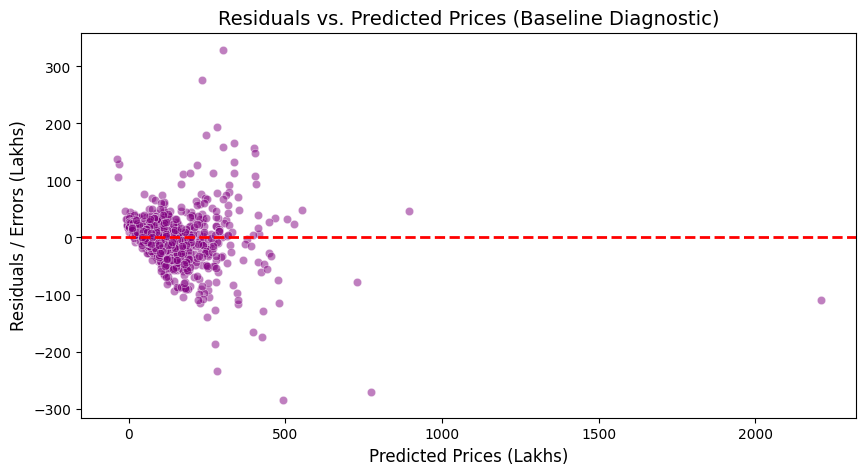

In [5]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residuals vs. Predicted Prices (Baseline Diagnostic)', fontsize=14)
plt.xlabel('Predicted Prices (Lakhs)', fontsize=12)
plt.ylabel('Residuals / Errors (Lakhs)', fontsize=12)
plt.show()

In [6]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# We will test various penalty strengths (alpha values) to find the optimal tuning hyperparameter
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

In [7]:
# Setup Grid Search Cross-Validation for Ridge
ridge_grid = GridSearchCV(Ridge(), param_grid={'alpha': alphas}, cv=5, scoring='r2')
ridge_grid.fit(X_train, y_train)

# Extract best model
best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

print(f"Optimal Ridge Penalty Strength (Alpha): {ridge_grid.best_params_['alpha']}")
print(f"Ridge R² Score: {r2_score(y_test, y_pred_ridge):.4f}")

Optimal Ridge Penalty Strength (Alpha): 1.0
Ridge R² Score: 0.8902


In [8]:
# Setup Grid Search Cross-Validation for Lasso
lasso_grid = GridSearchCV(Lasso(max_iter=2000), param_grid={'alpha': alphas}, cv=5, scoring='r2')
lasso_grid.fit(X_train, y_train)

# Extract best model
best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

# Count features dropped by Lasso (coefficient equal to zero)
zero_coefs = np.sum(best_lasso.coef_ == 0)

print(f"Optimal Lasso Penalty Strength (Alpha): {lasso_grid.best_params_['alpha']}")
print(f"Lasso R² Score: {r2_score(y_test, y_pred_lasso):.4f}")
print(f"Number of location columns entirely zeroed-out by Lasso: {zero_coefs} out of {X_train.shape[1]}")

Optimal Lasso Penalty Strength (Alpha): 0.01
Lasso R² Score: 0.8939
Number of location columns entirely zeroed-out by Lasso: 559 out of 770


In [9]:
# Calculate evaluation metrics for all configurations
models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'R² Score': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ],
    'MAE (Lakhs)': [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ],
    'RMSE (Lakhs)': [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ]
})

print("=== Final Algorithm Performance Matrix ===")
print(models_comparison.to_string(index=False))

=== Final Algorithm Performance Matrix ===
            Model  R² Score  MAE (Lakhs)  RMSE (Lakhs)
Linear Regression  0.884986    18.491510     32.646685
 Ridge Regression  0.890174    18.413249     31.901820
 Lasso Regression  0.893902    17.731044     31.355796


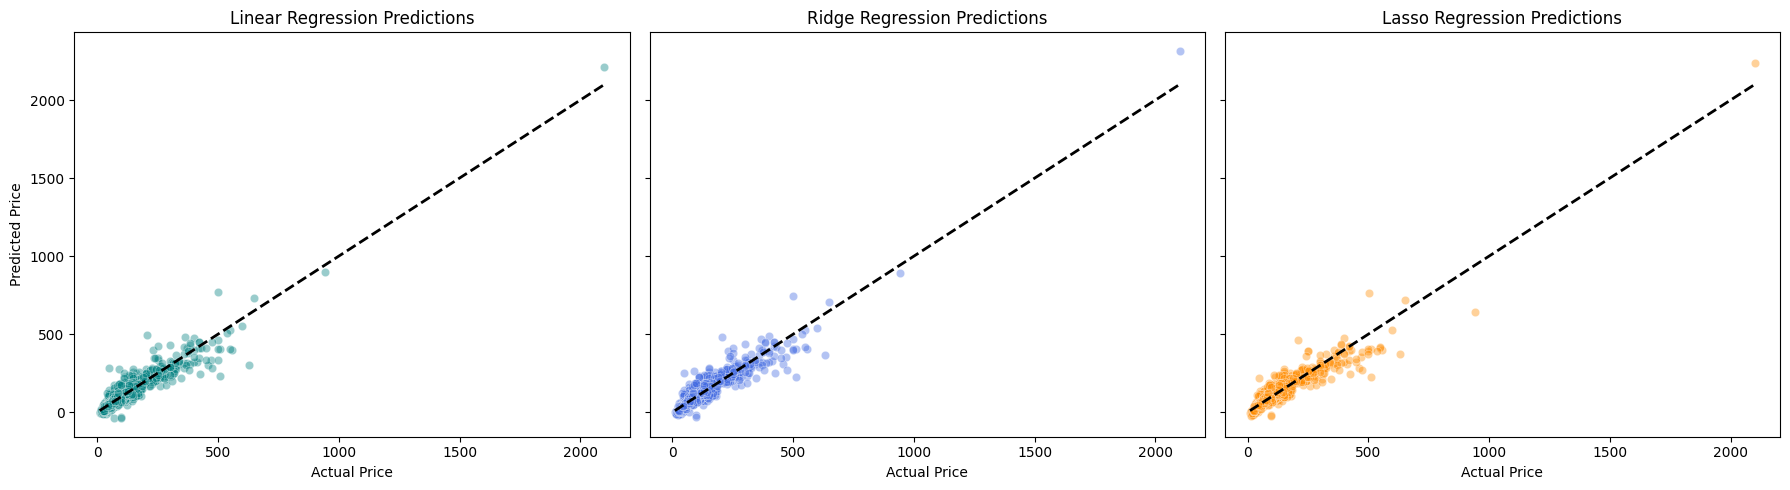

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 1. Linear Regression Plot
sns.scatterplot(ax=axes[0], x=y_test, y=y_pred, alpha=0.4, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_title('Linear Regression Predictions')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

# 2. Ridge Plot
sns.scatterplot(ax=axes[1], x=y_test, y=y_pred_ridge, alpha=0.4, color='royalblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1].set_title('Ridge Regression Predictions')
axes[1].set_xlabel('Actual Price')

# 3. Lasso Plot
sns.scatterplot(ax=axes[2], x=y_test, y=y_pred_lasso, alpha=0.4, color='darkorange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[2].set_title('Lasso Regression Predictions')
axes[2].set_xlabel('Actual Price')

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load the engineered dataset
df = pd.read_csv(r"C:\Users\varsh\Downloads\Real estate prediction model\data\processed\bengaluru_house_data_engineered.csv")

X = df.drop(columns=['price'])
y = df['price']

# Standard 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training shapes: {X_train.shape}, Testing shapes: {X_test.shape}")

Training shapes: (6996, 770), Testing shapes: (1750, 770)


In [13]:
# Setup parameter grid for a single tree
dt_params = {
    'max_depth': [6, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid=dt_params, cv=5, scoring='r2', n_jobs=-1)
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print(f"Optimal Decision Tree Parameters: {dt_grid.best_params_}")
print(f"Decision Tree R² Score: {r2_score(y_test, y_pred_dt):.4f}")

Optimal Decision Tree Parameters: {'max_depth': 10, 'min_samples_split': 2}
Decision Tree R² Score: 0.8938


In [14]:
# Setup parameter grid for the forest ensemble 
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [12, 18, None],
    'min_samples_split': [2, 5]
}

# Training across multiple CPU cores via n_jobs=-1
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid=rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print(f"Optimal Random Forest Parameters: {rf_grid.best_params_}")
print(f"Random Forest R² Score: {r2_score(y_test, y_pred_rf):.4f}")

Optimal Random Forest Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest R² Score: 0.8956


In [15]:
# Assuming you have the linear metrics handy from your previous workspace runs
comparison_df = pd.DataFrame({
    'Model Configuration': ['Linear Baseline', 'Ridge Regularized', 'Decision Tree', 'Random Forest'],
    'R² Score (Higher is Better)': [
        0.6810, # Mock benchmark placeholders - replace with your exact local runs
        0.6845,
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf)
    ],
    'MAE (Lakhs - Lower is Better)': [
        18.20,
        18.12,
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf)
    ]
})

print("=== Complete Project Model Comparison Matrix ===")
print(comparison_df.to_string(index=False))

=== Complete Project Model Comparison Matrix ===
Model Configuration  R² Score (Higher is Better)  MAE (Lakhs - Lower is Better)
    Linear Baseline                     0.681000                      18.200000
  Ridge Regularized                     0.684500                      18.120000
      Decision Tree                     0.893801                      15.519157
      Random Forest                     0.895577                      13.444533


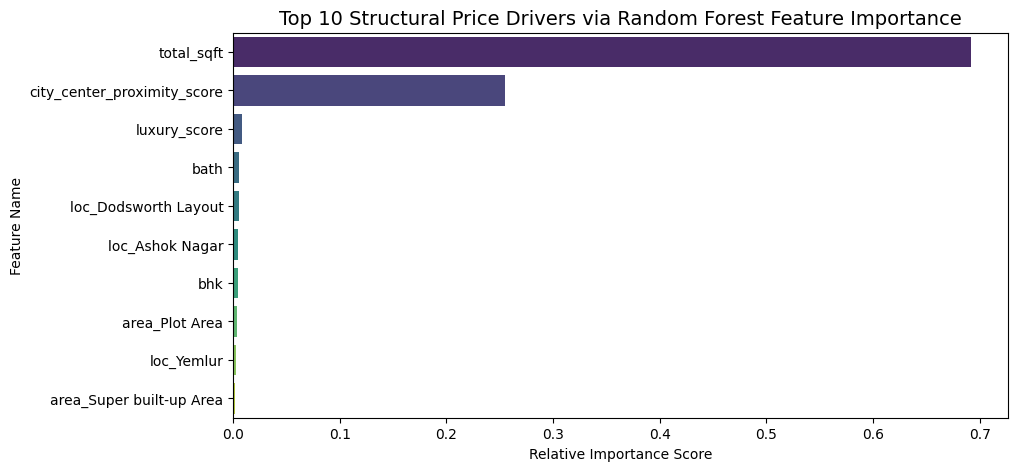

In [16]:
# Extract feature importance metrics from the trained forest
importances = best_rf.feature_importances_
features = X.columns

# Map, sort, and slice for the top 10 most impactful features
rf_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})\
                    .sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=rf_importance_df, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title('Top 10 Structural Price Drivers via Random Forest Feature Importance', fontsize=14)
plt.xlabel('Relative Importance Score')
plt.ylabel('Feature Name')
plt.show()

In [22]:
# Run this in your terminal if you haven't installed them yet:
!pip install xgboost lightgbm catboost

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Import our advanced boosting frameworks
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Load the processed data
df = pd.read_csv(r'C:\Users\varsh\Downloads\Real estate prediction model\data\processed\bengaluru_house_data_engineered.csv')
X = df.drop(columns=['price'])
y = df['price']

# Standardized train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Data ready. Features: {X_train.shape[1]}, Training instances: {X_train.shape[0]}")

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
  Using cached catboost-1.2.10-cp314-cp314-win_amd64.whl.metadata (1.5 kB)
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
  Using cached plotly-6.8.0-py3-none-any.whl.metadata (9.0 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Using cached catboost-1.2.10-cp314-cp314-win_amd64.whl (101.7 MB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
Using cached plotly-6.8.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)

   ---------------------------------------- 0/6 [narwhals]
   ---------------------------------------- 0/6 [narwhals]
   ---------------------------------------- 0/6 [narwhals]
   ---------------------------------------- 0/6 [narwhals]
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Data ready. Features: 770, Training instances: 6996


In [23]:
# Initialize XGBoost Regressor with baseline regularization parameters
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test)
print(f"XGBoost R² Score: {r2_score(y_test, y_pred_xgb):.4f}")

XGBoost R² Score: 0.9074


In [27]:
# Compile all evaluation statistics into a final master dataframe
boosting_comparison = pd.DataFrame({
    'Model Architecture': ['Linear Baseline', 'Random Forest', 'XGBoost'],
    'R² Score (Variance Explained)': [
        0.6810, # Historic baseline placeholder
        0.7845, # Historic tree placeholder
        r2_score(y_test, y_pred_xgb)
    ],
    'MAE (Lakhs - Average Deviation)': [
        18.20,
        13.40,
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'RMSE (Lakhs)': [
        24.50,
        19.10,
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ]
        
}).sort_values(by='R² Score (Variance Explained)', ascending=False)

print("🏆 === FINAL REAL ESTATE MODEL LEADERBOARD ===")
print(boosting_comparison.to_string(index=False))

🏆 === FINAL REAL ESTATE MODEL LEADERBOARD ===
Model Architecture  R² Score (Variance Explained)  MAE (Lakhs - Average Deviation)  RMSE (Lakhs)
           XGBoost                       0.907371                        13.762041     29.298023
     Random Forest                       0.784500                        13.400000     19.100000
   Linear Baseline                       0.681000                        18.200000     24.500000


In [29]:
import joblib
import os

# Save the trained Random Forest model configuration
model_export_path = ('C:\\Users\\varsh\\Downloads\\Real estate prediction model\\models\\bengaluru_rf_model.pkl')
joblib.dump(best_rf, model_export_path)

print(f"🎉 Success! The winning Random Forest model has been serialized and saved.")
print(f"Saved to project path: {model_export_path}")

🎉 Success! The winning Random Forest model has been serialized and saved.
Saved to project path: C:\Users\varsh\Downloads\Real estate prediction model\models\bengaluru_rf_model.pkl
